In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("C:/ML_Projects/portfolio-management-system/data/stock_prices.csv",index_col=0,parse_dates=True)
df.head()

,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-02,72.333855,94.900497,67.832520,151.829544,5.963803
2020-01-03,71.630653,93.748497,67.477654,149.939041,5.868348
2020-01-06,72.201424,95.143997,69.276207,150.326538,5.892957
2020-01-07,71.861839,95.343002,69.142395,148.955933,5.964302
2020-01-08,73.017830,94.598503,69.634529,151.328537,5.975487


In [6]:
daily_return=df.pct_change()
daily_return=daily_return.dropna()
daily_return.head()

,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-03,-0.009722,-0.012139,-0.005232,-0.012451,-0.016006
2020-01-06,0.007968,0.014886,0.026654,0.002584,0.004194
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118,0.012107
2020-01-08,0.016086,-0.007809,0.007118,0.015928,0.001875
2020-01-09,0.021241,0.004799,0.010498,0.012493,0.010983


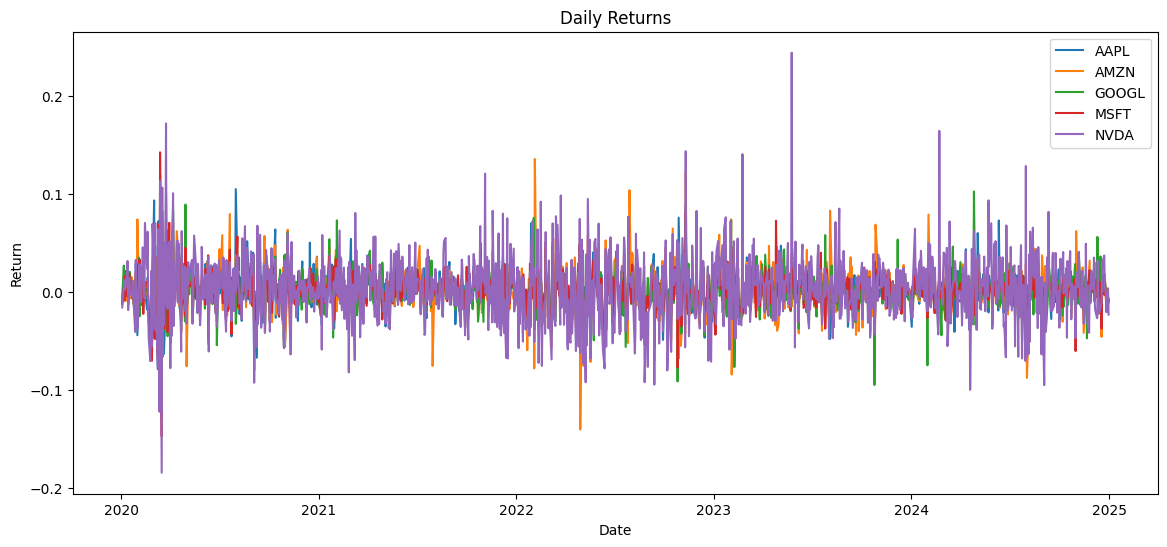

In [10]:
plt.figure(figsize=(14,6))
for stock in daily_return.columns:
    plt.plot(
        daily_return.index,
        daily_return[stock],
        label=stock
    )
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

In [11]:
daily_return.mean()

AAPL     0.001182
AMZN     0.000923
GOOGL    0.001022
MSFT     0.000988
NVDA     0.003050
dtype: float64

In [12]:
daily_return.std()

AAPL     0.019956
AMZN     0.022655
GOOGL    0.020472
MSFT     0.019211
NVDA     0.033940
dtype: float64

In [14]:
cummulative_return=(1+daily_return).cumprod()
cummulative_return.head()

,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-03,0.990278,0.987861,0.994768,0.987549,0.983994
2020-01-06,0.998169,1.002566,1.021283,0.990101,0.988121
2020-01-07,0.993474,1.004663,1.019310,0.981073,1.000084
2020-01-08,1.009456,0.996818,1.026566,0.996700,1.001959
2020-01-09,1.030897,1.001602,1.037343,1.009152,1.012963


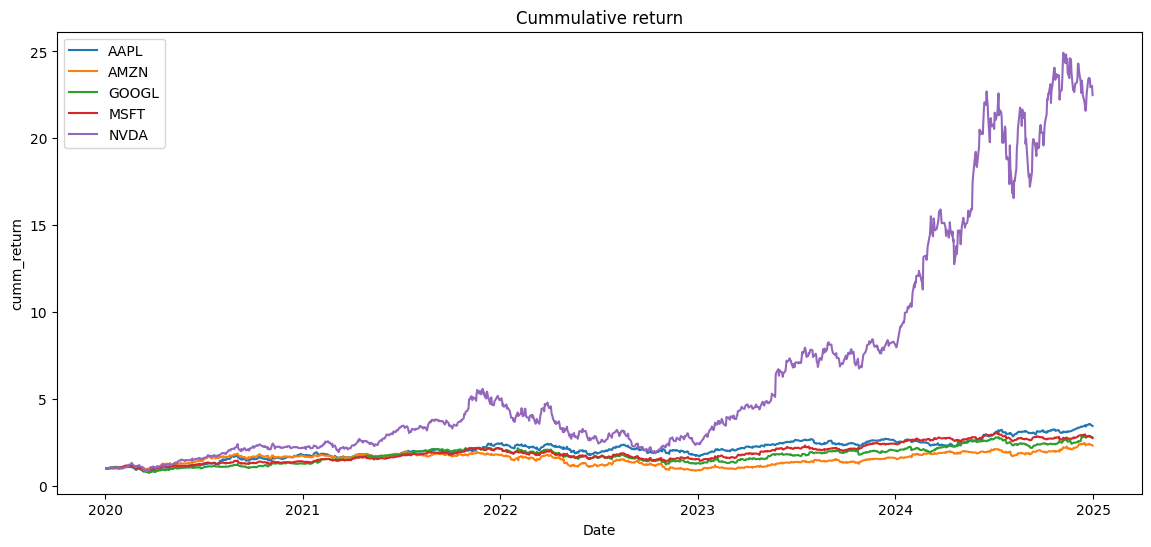

In [15]:
plt.figure(figsize=(14,6))
for stock in cummulative_return.columns:
    plt.plot(
        cummulative_return.index,
        cummulative_return[stock],
        label=stock
    )
plt.title("Cummulative return")
plt.xlabel("Date")
plt.ylabel("cumm_return")
plt.legend()
plt.show()
        
    

In [17]:
correlation=daily_return.corr()
correlation

,AAPL,AMZN,GOOGL,MSFT,NVDA
AAPL,1.000000,0.592200,0.648932,0.748327,0.606399
AMZN,0.592200,1.000000,0.647196,0.678500,0.579744
GOOGL,0.648932,0.647196,1.000000,0.746181,0.594137
MSFT,0.748327,0.678500,0.746181,1.000000,0.682141
NVDA,0.606399,0.579744,0.594137,0.682141,1.000000


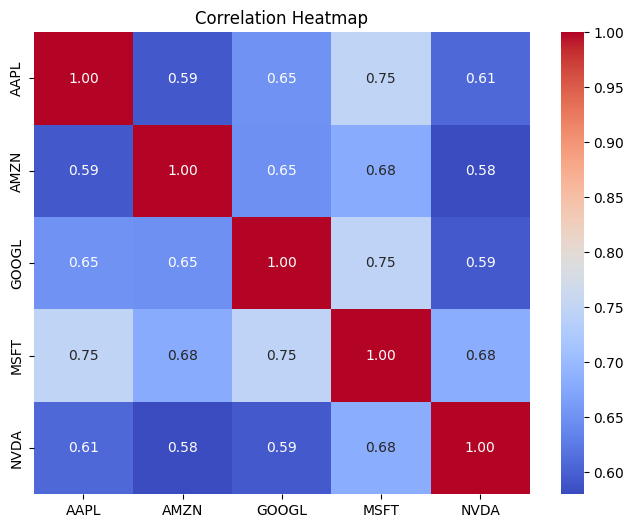

In [19]:
import seaborn as sns
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

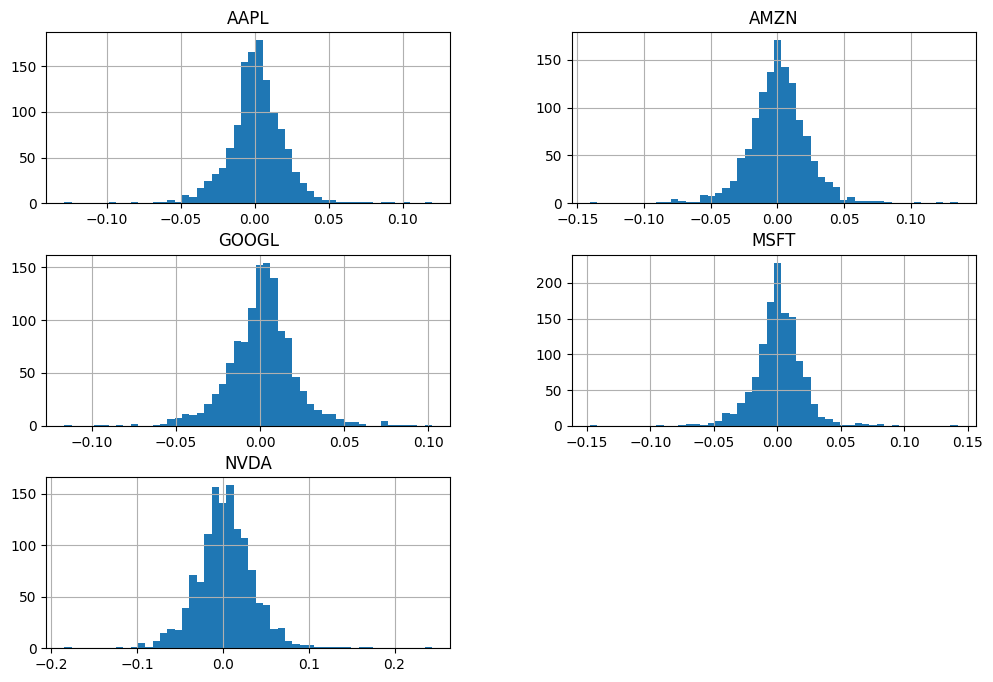

In [21]:
daily_return.hist(
    figsize=(12,8),
    bins=50
)
plt.show()

In [22]:
daily_return.to_csv(
    "../data/daily_return.csv"
)